# 2 — Ventilation, and why one number was never going to work

Recovering occupancy from CO₂ needs the room's air exchange rate. It is not
measured by anything here, but it is visible in the shape of every decay.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import figures
from load import load_clean

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
data = load_clean()
len(data)

from baseline import estimate_c_out
from ventilation import ach_series
data["c_out"] = estimate_c_out(data)

## The outdoor concentration is not 415 ppm

The room does not relax toward the street; it relaxes toward the air around it,
and that changes through the day. Assuming a fixed outdoor value put phantom
occupants in a room known to be empty.

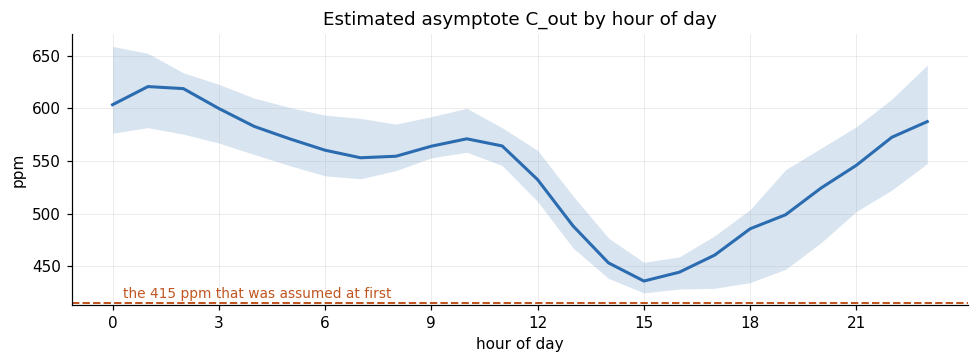

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.4))
figures.hour_profile(data.c_out, "ppm", "Estimated asymptote C_out by hour of day", ax=ax)
ax.axhline(415, color=figures.PALETTE["accent"], ls="--", lw=1.3)
ax.text(0.3, 420, "the 415 ppm that was assumed at first", color=figures.PALETTE["accent"], fontsize=9)
plt.tight_layout(); plt.show()

## Fitting the decays

Each sustained fall is fitted as `C(t) = C_out + A·exp(-k·t)`; the slope of
`ln(C - C_out)` gives k in air changes per hour.

air exchange rate:  median 0.90 ACH   p10 0.65   p90 1.17


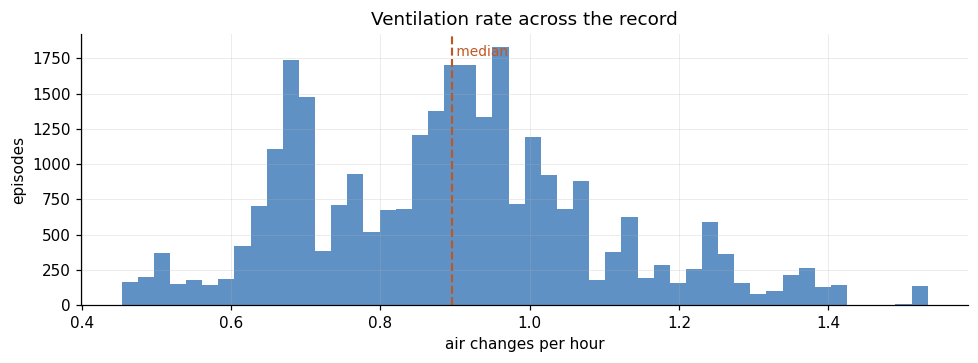

In [3]:
k = ach_series(data)
print(f"air exchange rate:  median {k.median():.2f} ACH   p10 {k.quantile(.1):.2f}   p90 {k.quantile(.9):.2f}")

fig, ax = plt.subplots(figsize=(9, 3.4))
figures.distribution(k.dropna(), "air changes per hour", "Ventilation rate across the record",
                     bins=50, vlines=[(k.median(), "median")], ax=ax)
plt.tight_layout(); plt.show()

A single constant k overestimates removal when the room is shut and
underestimates it when it is not — inventing occupants at night and hiding them
by day. That one wrong assumption produced both failures, in the right
direction each time.

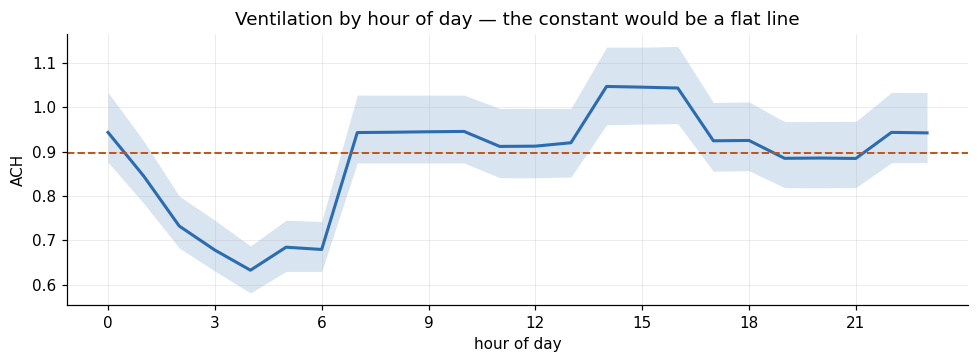

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.4))
figures.hour_profile(k, "ACH", "Ventilation by hour of day — the constant would be a flat line", ax=ax)
ax.axhline(k.median(), color=figures.PALETTE["accent"], ls="--", lw=1.3)
plt.tight_layout(); plt.show()